In [2]:
import pandas as pd 
import matplotlib as plt

In [3]:
df = pd.read_csv("data/processed/india_gdp_cleaned.csv")

df.head()


,Year,GDP
0,1960,3.702988e+10
1,1961,3.923244e+10
2,1962,4.216148e+10
3,1963,4.842192e+10
4,1964,5.648029e+10


In [4]:
df["Year"] = pd.to_datetime(df["Year"],format="%Y")

df = df.set_index("Year")

df.head()

,GDP
Year,
1960-01-01,3.702988e+10
1961-01-01,3.923244e+10
1962-01-01,4.216148e+10
1963-01-01,4.842192e+10
1964-01-01,5.648029e+10


In [5]:

from sklearn.linear_model import LinearRegression
import numpy as np

x = np.array(df.index.year).reshape(-1,1)
y = df["GDP"].values

model = LinearRegression()
model.fit(x, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [6]:
future_years = np.array(range(2024, 2031)).reshape(-1,1)
future_predictions = model.predict(future_years)

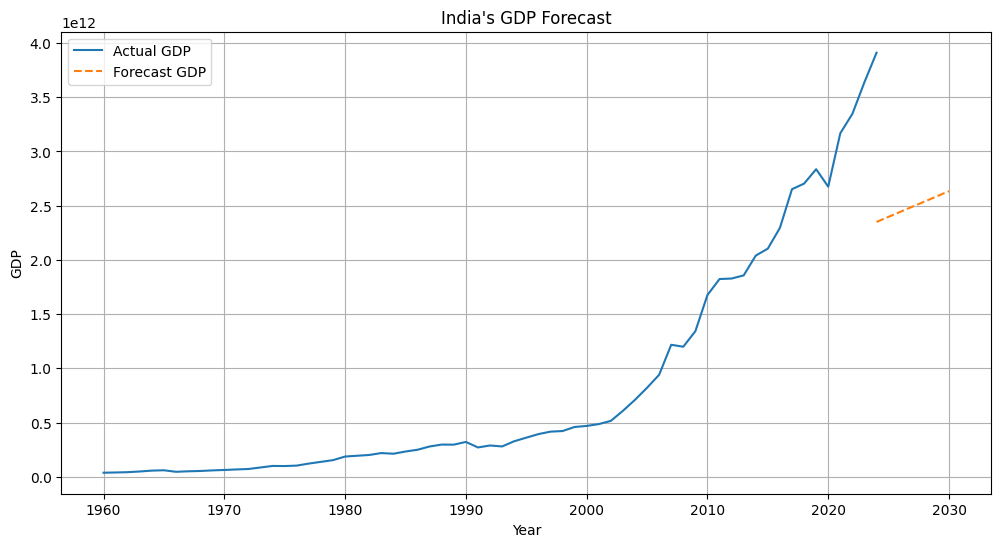

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df.index.year, y, label="Actual GDP")
plt.plot(future_years, future_predictions, linestyle = "dashed", label= "Forecast GDP")

plt.title("India's GDP Forecast")
plt.xlabel("Year")
plt.ylabel("GDP")
plt.legend()
plt.grid()

plt.show()

In [11]:
from prophet import Prophet

prophet_df = df.reset_index()

prophet_df = prophet_df.rename(columns={
    "Year": "ds",
    "GDP": "y"
})

prophet_df.head()

Importing plotly failed. Interactive plots will not work.


,ds,y
0,1960-01-01,3.702988e+10
1,1961-01-01,3.923244e+10
2,1962-01-01,4.216148e+10
3,1963-01-01,4.842192e+10
4,1964-01-01,5.648029e+10


In [12]:
model = Prophet()

model.fit(prophet_df)


11:13:18 - cmdstanpy - INFO - Chain [1] start processing
11:13:19 - cmdstanpy - INFO - Chain [1] done processing


In [13]:
future = model.make_future_dataframe(periods=10, freq="Y")

forecast = model.predict(future)

forecast.head()

/home/student/india-gdp-analysis/.venv/lib/python3.10/site-packages/prophet/forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1960-01-01,-7.801512e+11,-1.108953e+11,8.408543e+10,-7.801512e+11,-7.801512e+11,7.686647e+11,7.686647e+11,7.686647e+11,7.686647e+11,7.686647e+11,7.686647e+11,0.0,0.0,0.0,-1.148647e+10
1,1961-01-01,-7.717515e+11,-1.044273e+11,9.533525e+10,-7.717515e+11,-7.717515e+11,7.679561e+11,7.679561e+11,7.679561e+11,7.679561e+11,7.679561e+11,7.679561e+11,0.0,0.0,0.0,-3.795483e+09
2,1962-01-01,-7.633749e+11,-7.537690e+10,1.288525e+11,-7.633749e+11,-7.633749e+11,7.848964e+11,7.848964e+11,7.848964e+11,7.848964e+11,7.848964e+11,7.848964e+11,0.0,0.0,0.0,2.152156e+10
3,1963-01-01,-7.549982e+11,-6.720862e+10,1.283616e+11,-7.549982e+11,-7.549982e+11,7.851389e+11,7.851389e+11,7.851389e+11,7.851389e+11,7.851389e+11,7.851389e+11,0.0,0.0,0.0,3.014071e+10
4,1964-01-01,-7.466215e+11,-7.460426e+10,1.243434e+11,-7.466215e+11,-7.466215e+11,7.686647e+11,7.686647e+11,7.686647e+11,7.686647e+11,7.686647e+11,7.686647e+11,0.0,0.0,0.0,2.204319e+10


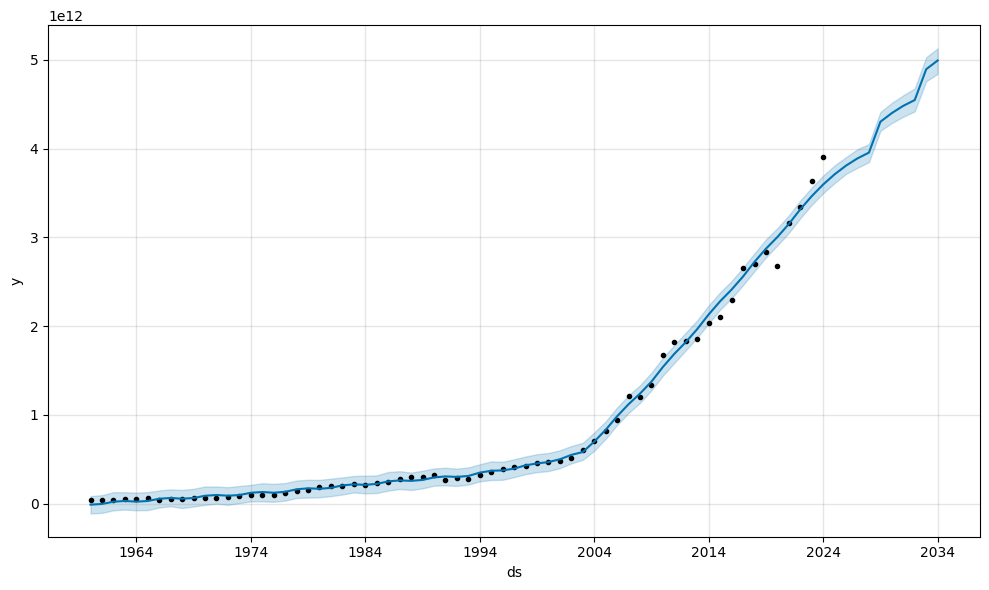

In [14]:
fig = model.plot(forecast)

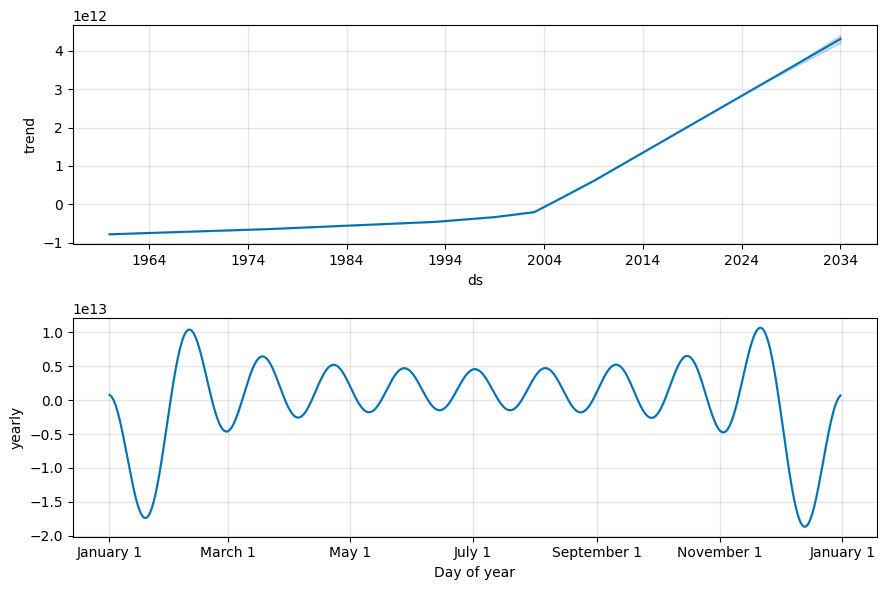

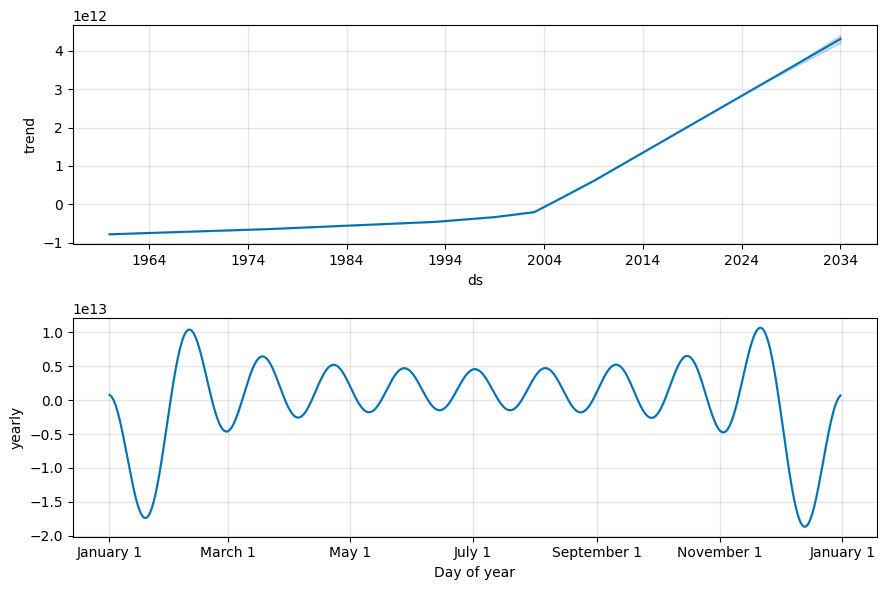

In [15]:
model.plot_components(forecast)